# Data Project

> **Note:** 
> 1. This is a starting point for how to structure your data project 
> 1. The `dataproject.py` file includes functions which can be in this notebook

Import and set magics:

In [14]:
# Import packages
import pandas as pd
import numpy as np
import requests
from io import StringIO
from dstapi import DstApi
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import PercentFormatter
from fredapi import Fred
import os

## Question 1.1

## Basics
#### Month-to-month inflation (how much prices changed compared to the previous month).
$$
π_t = P_t/P_{t−1} − 1
$$
#### 12-month inflation (how much prices changed compared to the same month a year earlier)
$$
π_t^{12}=P_t/P_{t-12}-1
$$
#### When did the post-pandemic inflation surge end in Denmark?

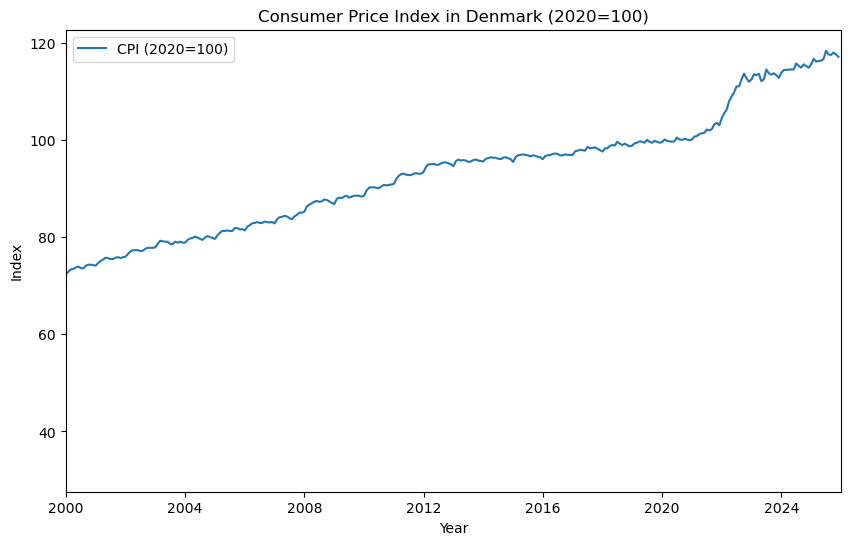

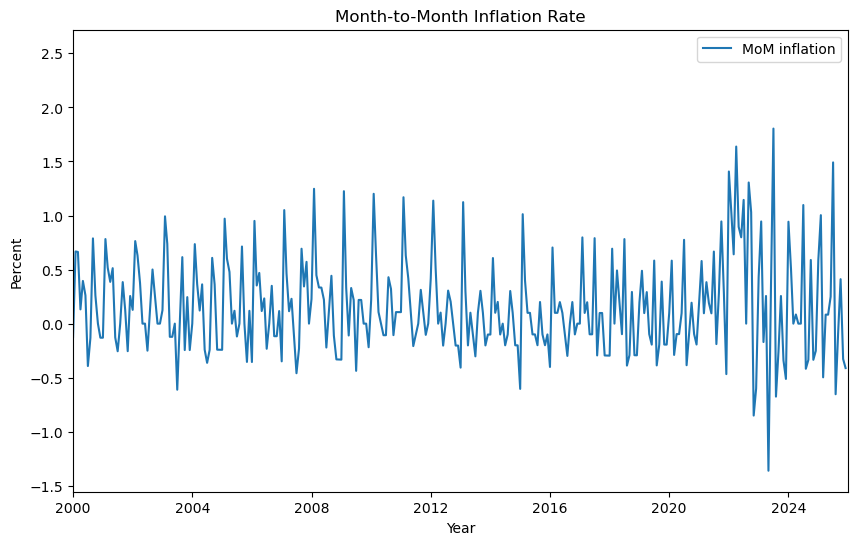

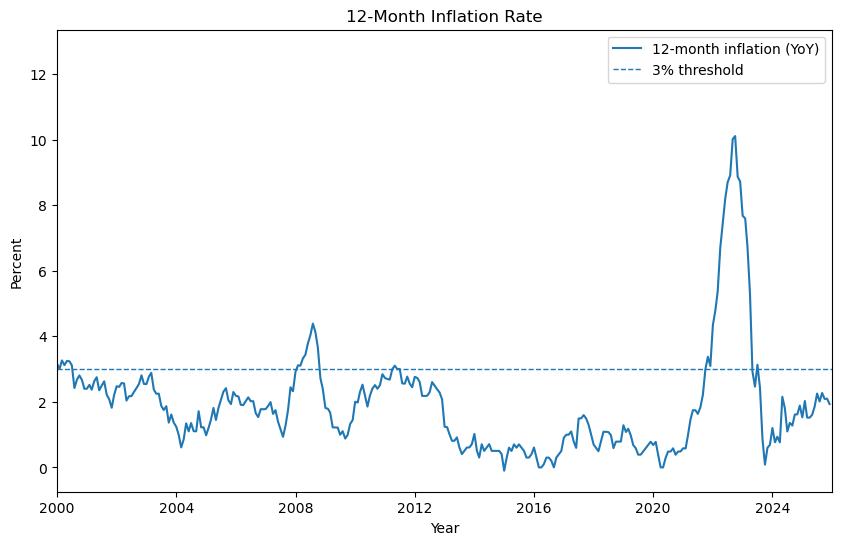

In [2]:
# Fetch the data from the API
pris113_api=DstApi('PRIS113')
params=pris113_api._define_base_params(language='en')
pris113_dat=pris113_api.get_data(params=params)
# Keep/rename relevant columns
cpi = pris113_dat.rename(columns={"TID": "date", "INDHOLD": "CPI", "TYPE": "type"}).copy()

#structuriing the date variable and converting to datetime
cpi['date'] = pd.to_datetime(cpi['date'], format='%YM%m')
cpi = cpi.sort_values('date')

# Ensure CPI column is numeric
cpi['CPI'] = pd.to_numeric(cpi['CPI'], errors='coerce')

# Set the CPI index to 100 in 2020
cpi['year'] = cpi['date'].dt.year
cpi_2020_mean = cpi.loc[cpi['year'] == 2020, 'CPI'].mean()
cpi['CPI_indexed'] = cpi['CPI'] / cpi_2020_mean * 100

# Inflation rate calculation
cpi['MoM_inflation'] = cpi['CPI_indexed'].pct_change() * 100
cpi['YoY_inflation'] = cpi['CPI_indexed'].pct_change(periods=12) * 100

# Plot CPI indexed to 2020
plt.figure(figsize=(10, 6))
plt.plot(cpi["date"], cpi["CPI_indexed"], label="CPI (2020=100)")
plt.title("Consumer Price Index in Denmark (2020=100)")
plt.xlabel("Year")
plt.ylabel("Index")
plt.xlim(pd.to_datetime("2000-01-01"), pd.to_datetime("2025-12-31"))
plt.legend()
plt.show()

# Plot Month-to-Month Inflation Rate
plt.figure(figsize=(10, 6))
plt.plot(cpi["date"], cpi["MoM_inflation"], label="MoM inflation")
plt.title("Month-to-Month Inflation Rate")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.xlim(pd.to_datetime("2000-01-01"), pd.to_datetime("2025-12-31"))
plt.legend()
plt.show()

# Plot 12-Month Inflation Rate
plt.figure(figsize=(10, 6))
plt.plot(cpi["date"], cpi["YoY_inflation"], label="12-month inflation (YoY)")
plt.axhline(3, linestyle="--", linewidth=1, label="3% threshold")
plt.title("12-Month Inflation Rate")
plt.xlabel("Year")
plt.ylabel("Percent")
plt.xlim(pd.to_datetime("2000-01-01"), pd.to_datetime("2025-12-31"))
plt.legend()
plt.show()


In [3]:
# Find when YoY inflation drops below 3% after the post-pandemic peak
cpi_post2020 = cpi[cpi["date"] >= pd.to_datetime("2020-01-01")].copy()

peak_idx = cpi_post2020["YoY_inflation"].idxmax()
peak_date = cpi_post2020.loc[peak_idx, "date"]

cpi_after_peak = cpi_post2020[cpi_post2020["date"] > peak_date]
end_surge_date = cpi_after_peak.loc[cpi_after_peak["YoY_inflation"] < 3, "date"].min()

print(f"Peak YoY inflation date: {peak_date:%Y-%m}")
print(f"YoY inflation fell below 3% again on: {end_surge_date:%Y-%m}" if pd.notna(end_surge_date) else "YoY inflation never fell below 3% in the sample after the peak.")


Peak YoY inflation date: 2022-10
YoY inflation fell below 3% again on: 2023-05


## Question 1.2 

# Instantaneous Inflation 
$$
\pi_{12, \alpha, t}
=
\left(
\prod_{k=0}^{11} (1 + \pi_{t-k})^{\kappa(k, \alpha)}
\right)
- 1
$$

where the weighting function is

$$
\kappa(k, \alpha)
=
\frac{(T - k)^{\alpha}}{\sum (T - k)^{\alpha}}T
$$

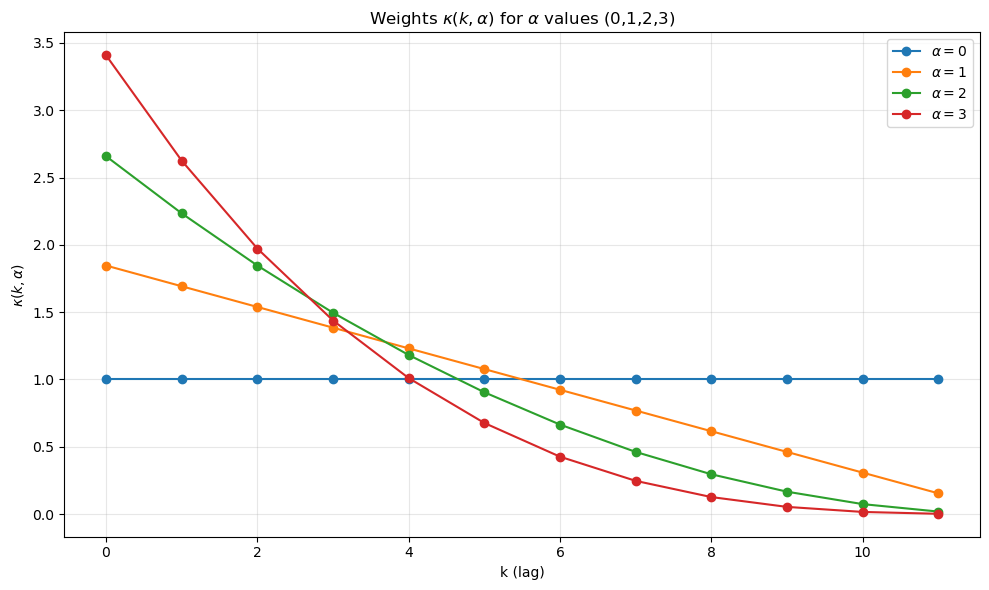

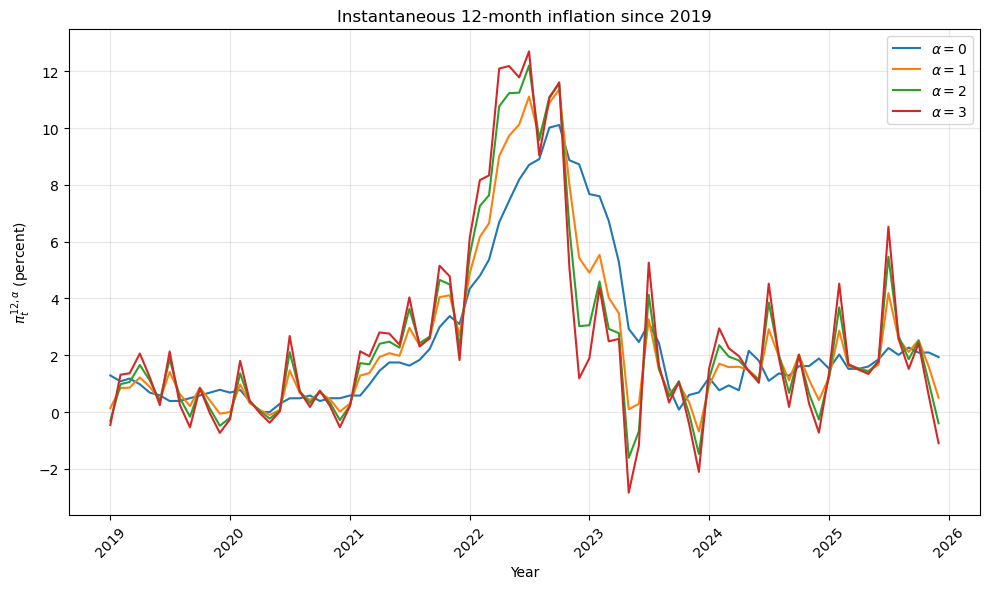

In [4]:
T = 12  # 12 months 

# Defining the weights function
def weights_kappa(alpha, T=12):
    k = np.arange(T)
    numer = (T - k) ** alpha
    kappa = T * numer / numer.sum()
    return k, kappa
alphas = [0, 1, 2, 3]

# Plot weights kappa(k, alpha)
fig, ax = plt.subplots(figsize=(10, 6))
for a in alphas:
    k, w = weights_kappa(a, T)
    ax.plot(k, w, marker="o", label=fr"$\alpha={a}$")
ax.set_title(r'Weights $\kappa(k, \alpha)$ for $\alpha$ values (0,1,2,3)')
ax.set_xlabel('k (lag)')
ax.set_ylabel(r'$\kappa(k, \alpha)$')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

def instantaneous_12m_inflation(pi_mom_dec, alpha, T=12):
    """
    pi_mom_dec: monthly inflation in decimals (e.g., 0.01 for 1%)
    returns: pi_t^{12,alpha} in decimals
    """
    _, w_kappa = weights_kappa(alpha, T)
    w = w_kappa[::-1]  # align so highest weight on most recent month

    return pi_mom_dec.rolling(T).apply(
        lambda x: np.prod((1 + x) ** w) - 1,
        raw=True
    )

# Compute once (outside loop)
cpi["MoM_inflation_dec"] = cpi["MoM_inflation"] / 100.0

# Plot instantaneous inflation since 2019
mask = cpi["date"] >= "2019-01-01"

fig, ax = plt.subplots(figsize=(10, 6))
for a in alphas:
    pi_inst = instantaneous_12m_inflation(cpi["MoM_inflation_dec"], a, T)
    ax.plot(cpi.loc[mask, "date"], 100 * pi_inst.loc[mask], label=fr"$\alpha={a}$")

ax.set_title("Instantaneous 12-month inflation since 2019")
ax.set_xlabel("Year")
ax.set_ylabel(r"$\pi_t^{12,\alpha}$ (percent)")
ax.legend()
ax.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## Question 1.3

## Core Inflation


In [5]:
# Initialize PRIS111 API object
PRIS111 = DstApi('PRIS111')

params = {
    'table': 'PRIS111',
    'format': 'BULK',
    'lang': 'en',
    'variables': [
        {'code': 'VAREGR', 'values': ['000000', '151000', '141000']},# toal CPI, excluding energy,excluding energy and processed food
        {'code': 'ENHED', 'values': ['100']},  # Index values
        {'code': 'Tid', 'values': ['*']}#all time periods
    ]
}
# Fetch the data
cpi_2 = PRIS111.get_data(params=params)
# print(cpi_2.head()) \check

# Convert TID to datetime first so it sorts correctly
cpi_2['TID'] = pd.to_datetime(
    cpi_2['TID'].astype(str).str.replace('M', '-', regex=False),
    format='%Y-%m',
    errors='coerce'
)

# Now sort by VAREGR (series) and then by time
cpi_2 = cpi_2.sort_values(['VAREGR', 'TID']).reset_index(drop=True)

# changing from string to float
cpi_2['INDHOLD'] = cpi_2['INDHOLD'].astype(float)

# display(cpi_2.head(515)) \check

In [6]:
# Calculate 12-month inflation for each VAREGR category
cpi_2 = cpi_2.sort_values(['VAREGR', 'TID'])
cpi_2['inflation_12month'] = cpi_2.groupby('VAREGR')['INDHOLD'].pct_change(12) * 100

# Keep only data from 2019 onwards
cpi_2 = cpi_2[cpi_2['TID'] >= '2019-01-01']

# display(cpi_2[['VAREGR', 'TID', 'INDHOLD', 'inflation_12month']].head(5)) \check

In [7]:



# renaming columns
cpi_2 = cpi_2.rename(columns={
    'VAREGR': 'Commodity Group',
    'ENHED': 'index100',
    'Tid': 'time'
})
#  display /check
# display(cpi_2.head(5))
# display(cpi_2.info())



/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_73855/3224078547.py:19: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_73855/3224078547.py:19: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


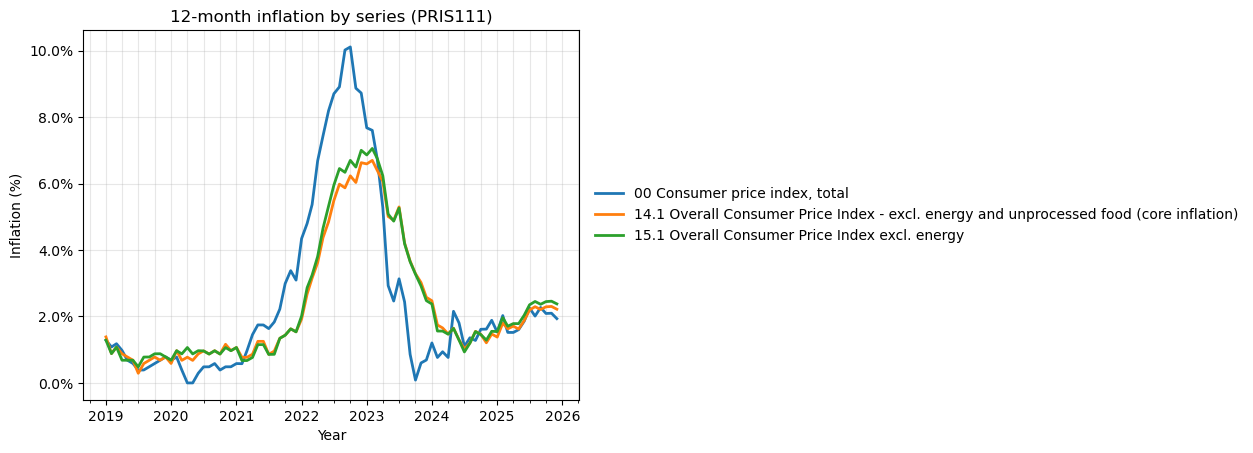

In [8]:
# Plotting the 12-month inflation by series
fig, ax = plt.subplots(constrained_layout=True)
for name, g in cpi_2.groupby('Commodity Group'):
    ax.plot(g['TID'], g['inflation_12month'], label=name,linewidth=2)

ax.set_title('12-month inflation by series (PRIS111)')
ax.set_xlabel('Year')
ax.set_ylabel('Inflation (%)')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.grid(alpha=0.3)
# Customize x-axis for better date representation
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator(bymonth=(1,4,7,10)))
# Add gridlines for minor ticks
ax.grid(which='both', alpha=0.3)
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5),
          frameon=False, borderaxespad=0)
plt.tight_layout()
plt.show()

### What does this tell us about the most likely drivers of the post-pandemic inflation surge in Denmark?

From this chart, Denmark’s post-pandemic inflation surge was driven mainly by energy:
* In late 2022–early 2023, headline CPI spiked to around 10%, while CPI excluding energy peaked around 6–7%. The 3-percentage-point gap at the top shows energy and food prices was the key force pushing inflation up.

* The “excl-energy” and “excl-energy & unprocessed food” lines almost overlap, indicating unprocessed food wasn’t an additional major driver. The point where energy stops being the main problem, but its ripple effects keep prices high for longer. Thus ,the persistence in 2023–2024 came from core inflation catching up, through cost pass-through and wage dynamics meaning.

# Question 1.4

## Disaggregated inflation in Denmark

### 1.4.1

In [9]:
api = DstApi("PRIS111")
# --- (1) Get 4-digit categories (IDs + text) ---
levels = api.variable_levels("VAREGR", language="en")

# Identify categories where the second-to-last digit ≠ 0 -> This must be a four digit category
categories_selected = [
    (row.id, row.text)
    for row in levels.itertuples()
    if isinstance(row.id, str) and len(row.id) == 6 and row.id[-2] != '0'
]

# Convert to DataFrame for display
cat_df = pd.DataFrame(categories_selected, columns=["VAREGR", "text"])

# display(cpi_3.head(227)) /check

# --- (2) Download index values for all 4-digit categories ---
params = {
    "table": "PRIS111",
    "format": "BULK",
    "lang": "en",
    "variables": [
        {"code": "VAREGR", "values": cat_df["VAREGR"].tolist()},
        {"code": "ENHED",  "values": ["100"]},
        {"code": "Tid",    "values": ["*"]},
    ]
}
df = api.get_data(params=params).copy()

# Clean
df["VAREGR"] = df["VAREGR"].astype(str).str.zfill(6)
df["TID"] = pd.to_datetime(df["TID"].astype(str).str.strip(), format="%YM%m", errors="coerce")
df["INDHOLD"] = pd.to_numeric(df["INDHOLD"], errors="coerce")
df = df.dropna(subset=["TID", "INDHOLD"])

df = df.sort_values(["VAREGR", "TID"])

# 12-month inflation (YoY) for each category (used in 1.4.2 and 1.4.4)
df["inflation_12m"] = df.groupby("VAREGR")["INDHOLD"].pct_change(12) * 100

### 1.4.2

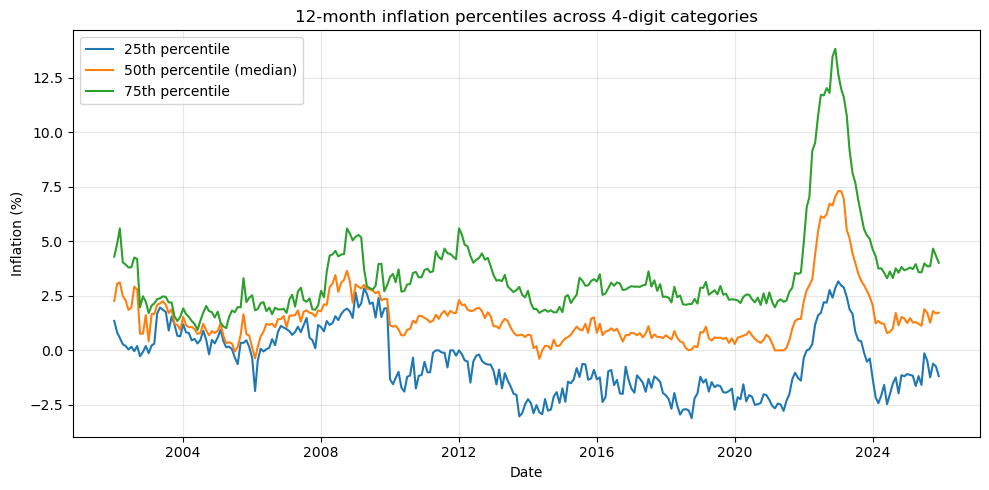

In [10]:
percentiles = (
    df.groupby("TID")["inflation_12m"]
      .agg(
          p25=lambda x: x.quantile(0.25),
          p50=lambda x: x.quantile(0.50),
          p75=lambda x: x.quantile(0.75),
      )
      .dropna()
)

plt.figure(figsize=(10, 5))
plt.plot(percentiles.index, percentiles["p25"], label="25th percentile")
plt.plot(percentiles.index, percentiles["p50"], label="50th percentile (median)")
plt.plot(percentiles.index, percentiles["p75"], label="75th percentile")
plt.title("12-month inflation percentiles across 4-digit categories")
plt.xlabel("Date")
plt.ylabel("Inflation (%)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Plot and describe what you see?

The 25th percentile (blue) is the lower quartile shows the products with below average inflation.
The 50th percentile (green) is the median inflation rate across all product categories.
The 75th percentile (red) is the uppwr quartile products with above-average inflation.

Before the pandemic, the three lines move in a fairly tight band and inflation across product categories is low and homogeneous.

After pandemic, there is a spike across the percentiles (25th above 3%, 50th around 7% and 75th above 13% ).

After the surge ended, the inflation level across percentiles rose. The gap between percentiles widened reflects increasing dispersion of inflation showing persistent heterogeneity where some sectors still face elevated price growth even as the median moderates.

### 1.4.3

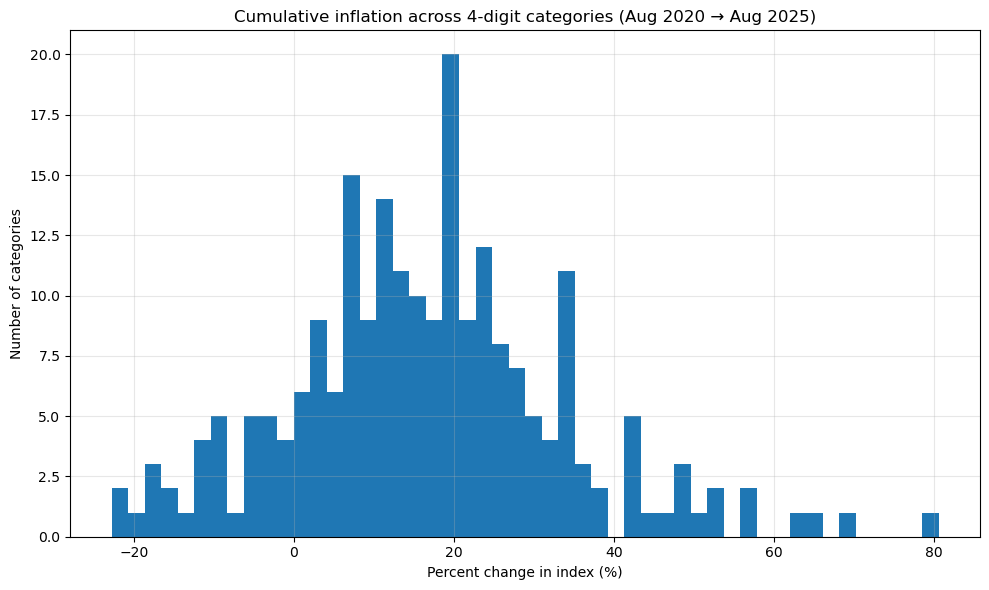

In [11]:
start = pd.Timestamp("2020-08-01")
end   = pd.Timestamp("2025-08-01")

start_idx = df.loc[df["TID"] == start, ["VAREGR", "INDHOLD"]].rename(columns={"INDHOLD": "P_start"})
end_idx   = df.loc[df["TID"] == end,   ["VAREGR", "INDHOLD"]].rename(columns={"INDHOLD": "P_end"})

cum = start_idx.merge(end_idx, on="VAREGR", how="inner")
cum["cum_inflation"] = (cum["P_end"] / cum["P_start"] - 1) * 100
cum = cum.dropna(subset=["cum_inflation"])

plt.figure(figsize=(10, 6))
plt.hist(cum["cum_inflation"], bins=50)
plt.title("Cumulative inflation across 4-digit categories (Aug 2020 → Aug 2025)")
plt.xlabel("Percent change in index (%)")
plt.ylabel("Number of categories")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## Describe what you see.

The histogram graphs have plotted to visualize the inflation rates across 4 digit product categories. The first graph has been plotted across two different scales of x axis to show any outliers.The histogram is skewed to the right showing positive inflation.The median category sits slightly above zero. The skewness tells us that inflation rose overtime as high-cost pressures spilled over into other product categories.Also due to price stickiness and downward rigidity,the fall is prices of goods is slower compared to its rise.

### 1.4.4

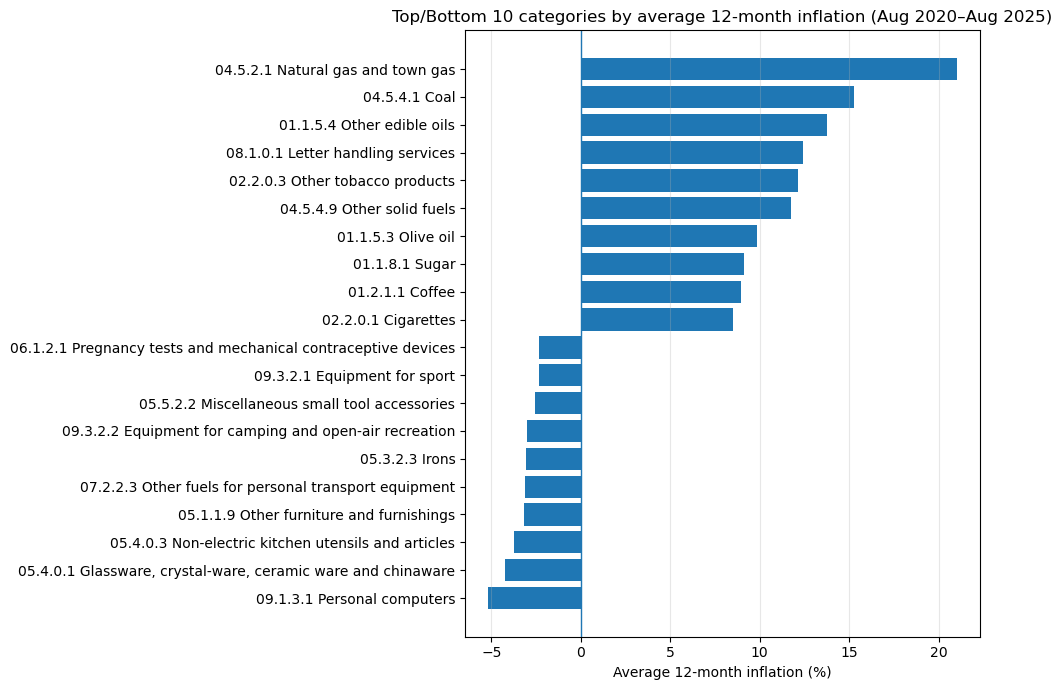

In [12]:
window = df[(df["TID"] >= start) & (df["TID"] <= end)].copy()

avg = (window.groupby("VAREGR")["inflation_12m"].mean()
             .dropna()
             .reset_index(name="avg_inflation_12m"))

top10 = avg.nlargest(10, "avg_inflation_12m").assign(group="Top 10")
bottom10 = avg.nsmallest(10, "avg_inflation_12m").assign(group="Bottom 10")
sel = pd.concat([top10, bottom10], ignore_index=True)

# add names (text) and build labels (avoid duplicates)
sel = sel.merge(cat_df[["VAREGR", "text"]], on="VAREGR", how="left")
sel["label"] = sel["text"].fillna(sel["VAREGR"])

# plot
sel_sorted = sel.sort_values("avg_inflation_12m")

plt.figure(figsize=(10, 7))
plt.barh(sel_sorted["label"], sel_sorted["avg_inflation_12m"])
plt.axvline(0, linewidth=1)
plt.title("Top/Bottom 10 categories by average 12-month inflation (Aug 2020–Aug 2025)")
plt.xlabel("Average 12-month inflation (%)")
plt.ylabel("")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


What the histogram in 1.4.3 shows (cumulative inflation from Aug 2020 → Aug 2025 across 4-digit categories): 
* The distribution is mostly positive: most categories experienced price increases over the period.
* The bulk of observations seems to lie roughly between 0% and 30%, with the highest concentration around about 15–25% cumulative change.
* There is a left tail below zero: a smaller set of categories had negative cumulative inflation (price declines), down to around −20% to −25%.
* The distribution has a long right tail (right-skewed): a few categories show very large cumulative increases, reaching roughly 60–80%.
* Overall: moderate inflation for most categories, but strong heterogeneity—a handful of categories drive very large increases while some categories fall in price.

# Question 2.1

### CPI vs HICP

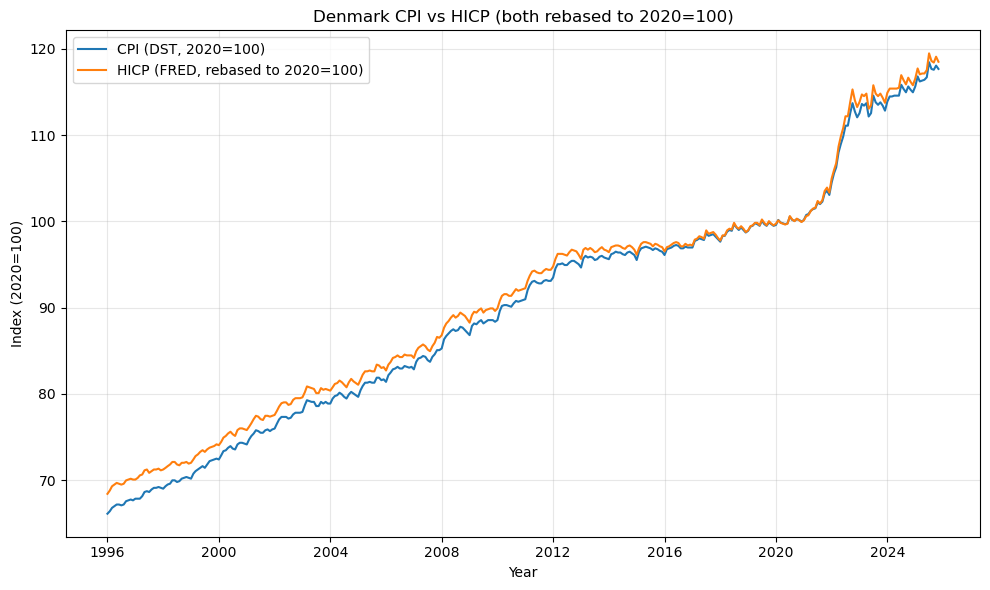

In [19]:
cpi_comp = cpi[["date", "CPI_indexed"]].dropna().copy()

# access Fed data
with open("fredapi.txt", "r") as f:
    fred_api_key = f.read().strip()
fred = Fred(api_key=fred_api_key)


hicp = fred.get_series('CP0000DKM086NEST')
hicp = hicp.rename("HICP").to_frame()
hicp.index = pd.to_datetime(hicp.index)
hicp = hicp.sort_index()
hicp.head()

hicp_2020_mean = hicp.loc["2020-01-01":"2020-12-31", "HICP"].mean()
hicp["HICP_2020_100"] = 100 * hicp["HICP"] / hicp_2020_mean

cpi_comp = cpi[["date", "CPI_indexed"]].dropna().copy()
hicp_comp = hicp.reset_index().rename(columns={"index": "date"})[["date", "HICP_2020_100"]]

# 合併共同日期
comp = pd.merge(cpi_comp, hicp_comp, on="date", how="inner")
comp.head()

plt.figure(figsize=(10, 6))
plt.plot(comp["date"], comp["CPI_indexed"], label="CPI (DST, 2020=100)")
plt.plot(comp["date"], comp["HICP_2020_100"], label="HICP (FRED, rebased to 2020=100)")
plt.title("Denmark CPI vs HICP (both rebased to 2020=100)")
plt.xlabel("Year")
plt.ylabel("Index (2020=100)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()



#### Short Answer:
The key difference between HICP and CPI is whether the index includes own-occupied hosuing. Accroding to the plot above, both indexs are nearly consistent.

# Question 2.2

### 1. Compare HICP (All Items) across countries

In [ ]:
countriesHICP = {'CP0000DKM086NEST': 'HICP Denmark', 
                 'CP0000ATM086NEST': 'HICP Austria',
                 'CP0000EZ19M086NEST': 'HICP Euro Area',
                 'CP0000USM086NEST': 'HICP USA'
                 }

In [ ]:
for k in countriesHICP.keys():
    display(fred.search(k)[['title','frequency','units']].T)

series id,CP0000DKM086NEST
title,Harmonized Index of Consumer Prices: All-Items...
frequency,Monthly
units,Index 2015=100


series id,CP0000ATM086NEST
title,Harmonized Index of Consumer Prices: All-Items...
frequency,Monthly
units,Index 2015=100


series id,CP0000EZ19M086NEST
title,Harmonized Index of Consumer Prices: All-Items...
frequency,Monthly
units,Index 2015=100


series id,CP0000USM086NEST
title,Harmonized Index of Consumer Prices: All-Items...
frequency,Monthly
units,Index 2015=100


In [ ]:
data1 = {}
for code,name in countriesHICP.items():
    var = fred.get_series(code)
    var.name = name
    data1[name] = var
    print(f'Downloaded {code:15s} from FRED and saved it as {name:15s}')

## Resample to annual frequency
for name,var in data1.items():
    data1[name] = var.resample("YE").mean()

## Combine and drop any rows with missing observations
df1 = pd.concat(data1, axis=1).dropna()

# Retain after 2019
df1 = df1.loc['2019':]    

## Change index to year
# Change index to year only
df1.index = df1.index.year
df1 = df1.rename_axis('year')
df1.head()

Downloaded CP0000DKM086NEST from FRED and saved it as HICP Denmark   
Downloaded CP0000ATM086NEST from FRED and saved it as HICP Austria   
Downloaded CP0000EZ19M086NEST from FRED and saved it as HICP Euro Area 
Downloaded CP0000USM086NEST from FRED and saved it as HICP USA       


,HICP Denmark,HICP Austria,HICP Euro Area,HICP USA
year,,,,
2019,102.533333,106.983333,104.800000,105.986667
2020,102.875000,108.468333,105.064167,106.801667
2021,104.875000,111.460833,107.783333,112.500833
2022,113.825000,121.066667,116.820000,122.265000
2023,117.641667,130.399167,123.135000,125.940833


### Graph

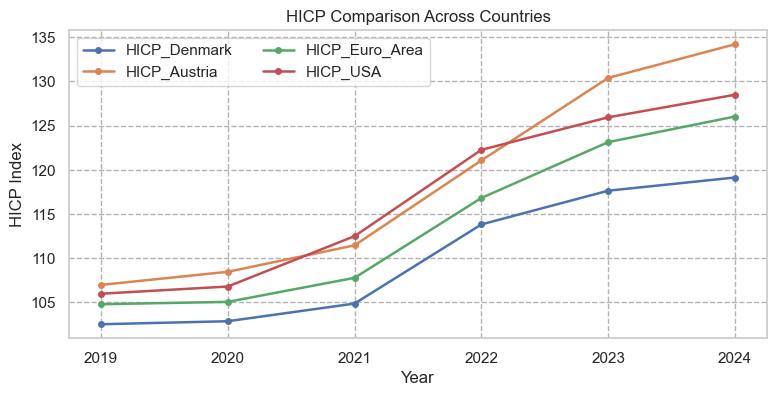

In [ ]:
HICP_DK = df1['HICP Denmark']
HICP_AT = df1['HICP Austria']
HICP_EA = df1['HICP Euro Area']
HICP_US = df1['HICP USA']

# Match same years
all_series = {'HICP_Denmark': HICP_DK, 'HICP_Austria': HICP_AT, 'HICP_Euro_Area': HICP_EA, 'HICP_USA': HICP_US}
df_all = pd.concat(all_series, axis=1).dropna().sort_index()

# Draw at the same plot
fig, ax = plt.subplots(figsize=(9, 4))

for col in df_all.columns:
    ax.plot(
        df_all.index, df_all[col],
        marker='o',           
        markersize=4,         
        linewidth=1.8,
        label=col
    )
ax.set_xlabel('Year')
ax.set_ylabel('HICP Index')
ax.set_title('HICP Comparison Across Countries')
ax.legend(ncol=2)          
ax.grid(True, ls='--', alpha=0.3)



### 2. Compute and compare the 12-month HICP inflation rate across countries

$$
\pi_t = \left( \frac{\mathrm{HICP}_t}{\mathrm{HICP}_{t-12}} - 1 \right) \times 100
$$

In [ ]:
data_m = {}
for code,name in countriesHICP.items():
    var = fred.get_series(code)
    var.name = name
    data_m[name] = var
    print(f'Downloaded {code:15s} from FRED and saved it as {name:15s}')
# 1) Combine each countries' HICP
df_m = pd.concat(data_m, axis=1).sort_index()

# 2) from 2019
df_m = df_m.loc['2019-01':]

# 3) inflation（YoY）
yoy = df_m.pct_change(12) * 100
# yoy = (np.log(df_m) - np.log(df_m.shift(12))) * 100

# 4) drop na
yoy = yoy.dropna()
yoy.head()  

Downloaded CP0000DKM086NEST from FRED and saved it as HICP Denmark   
Downloaded CP0000ATM086NEST from FRED and saved it as HICP Austria   
Downloaded CP0000EZ19M086NEST from FRED and saved it as HICP Euro Area 
Downloaded CP0000USM086NEST from FRED and saved it as HICP USA       


/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_63379/1881716579.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy = df_m.pct_change(12) * 100


,HICP Denmark,HICP Austria,HICP Euro Area,HICP USA
2020-01-01,0.785855,2.168150,1.359619,2.223500
2020-02-01,0.684262,2.187293,1.219748,2.050940
2020-03-01,0.292969,1.582249,0.747484,1.042555
2020-04-01,-0.097371,1.521658,0.313987,-0.471076
2020-05-01,-0.194742,0.587796,0.085519,-0.742760


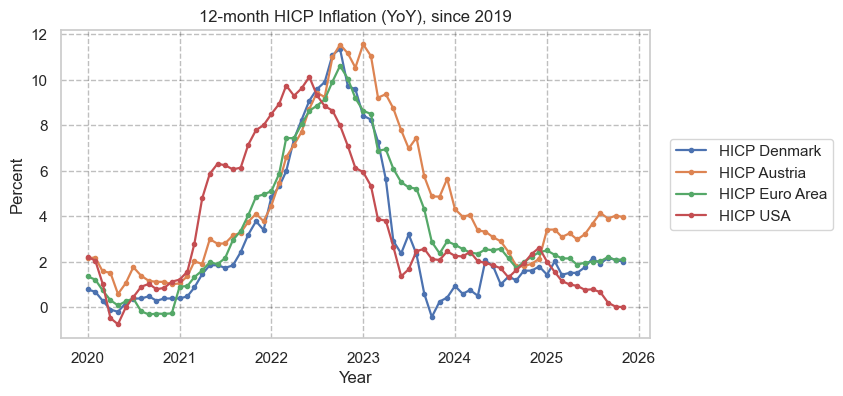

In [ ]:
# 5) Plotting
fig, ax = plt.subplots(figsize=(9,4))
for col in yoy.columns:
    ax.plot(yoy.index, yoy[col], marker='o', markersize=3, linewidth=1.6, label=col)
ax.set_title('12-month HICP Inflation (YoY), since 2019')
ax.set_xlabel('Year'); ax.set_ylabel('Percent')
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
fig.subplots_adjust(right=0.78)

### 3. Print the min., max., and mean 12-month inflation rate year-by-year and across countries

In [ ]:
# 1) select last observation of each year (usually December) for YoY
yoy_year = yoy.resample('Y').last()
yoy_year.index = yoy_year.index.year
yoy_year.index.name = 'year'

# 2) Calculate min, max, mean across countries
stats = pd.DataFrame({
    'min':  yoy_year.min(axis=1),
    'max':  yoy_year.max(axis=1),
    'mean': yoy_year.mean(axis=1),
})

# 3) which country has min and max
who = pd.DataFrame({
    'min_country': yoy_year.idxmin(axis=1),
    'max_country': yoy_year.idxmax(axis=1),
})

summary = stats.join(who)

print(summary.round(2))

       min    max  mean     min_country   max_country
year                                                 
2020 -0.27   1.13  0.57  HICP Euro Area      HICP USA
2021  3.40   8.01  5.04    HICP Denmark      HICP USA
2022  6.13  10.54  8.86        HICP USA  HICP Austria
2023  0.43   5.65  2.86    HICP Denmark  HICP Austria
2024  1.79   2.62  2.24    HICP Denmark      HICP USA
2025  0.01   3.97  2.03        HICP USA  HICP Austria


/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_63379/4223572299.py:2: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  yoy_year = yoy.resample('Y').last()


### Summary

Since 2019, all countries have experienced the same inflation cycle, but with significant differences in intensity and speed:
* Austria has the highest cumulative increase and stickiness
* The United States peaked first and deflated the fastest
* Denmark has the most significant decline in Europe
* The eurozone as a whole is somewhere in between

By 2024-2025, the cross-national inflation rate has converged significantly to around 2%, but it is still higher in Austria and lower in the United States.

# Question 3

### Energy price v.s. HICP inflation

* Idea: Using Brent crude oil as a proxy for energy costs, I'll check how the YoY oil price correlates with the YoY HICP rates for various countries.

* Why Brent crude oil ? Brent crude oil is a primary global benchmark for oil pricing.

/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_63379/241167025.py:14: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy = df_m.pct_change(12) * 100


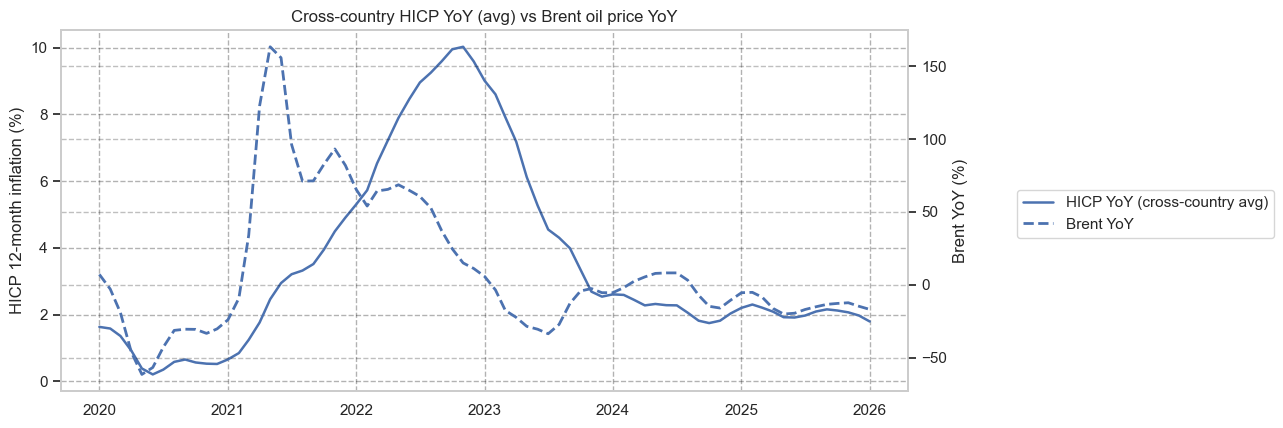

In [ ]:
# --- 1) Download monthly series: HICP (countries) + Brent oil price ---
series_map = dict(countriesHICP)  # e.g. {"CP0000DKM086NEST":"Denmark", ...}
series_map["DCOILBRENTEU"] = "Brent"  # raw price level

monthly = {}
for code, name in series_map.items():
    s = fred.get_series(code).resample("MS").mean()  # Make monthly series (month start); average within month if higher frequency
    s.name = name
    monthly[name] = s

df_m = pd.concat(monthly, axis=1).sort_index().loc["2019-01-01":]

# --- 2) Compute YoY inflation/changes (12-month % change) ---
yoy = df_m.pct_change(12) * 100
yoy = yoy.dropna()

# 3-month smoothing
yoy_sm = yoy.rolling(3, min_periods=1).mean()

# Cross-country average HICP YoY (exclude Brent column)
hicp_cols = [c for c in yoy_sm.columns if c != "Brent"]
hicp_mean = yoy_sm[hicp_cols].mean(axis=1)
brent_yoy = yoy_sm["Brent"]

# --- 3) Plot: HICP YoY mean vs Brent YoY (twin axis) ---
fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.plot(hicp_mean.index, hicp_mean, linewidth=1.8, label="HICP YoY (cross-country avg)")
ax1.set_ylabel("HICP 12-month inflation (%)")
ax1.grid(True, ls="--", alpha=0.3)
ax1.xaxis.set_major_locator(mdates.YearLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax2 = ax1.twinx()
ax2.plot(brent_yoy.index, brent_yoy, linestyle="--", linewidth=2.0, label="Brent YoY")
ax2.set_ylabel("Brent YoY (%)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
fig.legend(h1+h2, l1+l2, loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.subplots_adjust(right=0.78)

ax1.set_title("Cross-country HICP YoY (avg) vs Brent oil price YoY")
plt.tight_layout()
plt.show()


In [ ]:
for code,name in countriesHICP.items():
    var = fred.get_series(code)
    var.name = name
    data[name] = var
    print(f'Downloaded {code:15s} from FRED and saved it as {name:15s}')
# 1) Combine each countries' HICP
df_m = pd.concat(data, axis=1).sort_index()

# 2) from 2019
df_m = df_m.loc['2019-01':]

# 3) inflation（YoY）
yoy = df_m.pct_change(12) * 100
# yoy = (np.log(df_m) - np.log(df_m.shift(12))) * 100

# 4) drop na
yoy = yoy.dropna()
yoy.head()  

Downloaded CP0000DKM086NEST from FRED and saved it as HICP Denmark   
Downloaded CP0000ATM086NEST from FRED and saved it as HICP Austria   
Downloaded CP0000EZ19M086NEST from FRED and saved it as HICP Euro Area 
Downloaded CP0000USM086NEST from FRED and saved it as HICP USA       


/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_63379/794413132.py:13: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy = df_m.pct_change(12) * 100


,HICP Denmark,HICP Austria,HICP Euro Area,HICP USA
2020-01-01,0.785855,2.168150,1.359619,2.223500
2020-02-01,0.684262,2.187293,1.219748,2.050940
2020-03-01,0.292969,1.582249,0.747484,1.042555
2020-04-01,-0.097371,1.521658,0.313987,-0.471076
2020-05-01,-0.194742,0.587796,0.085519,-0.742760


* The surge in oil prices in 2022 contributed significantly to inflation; after oil prices fell, inflation followed suit.

* Brent oil price appears to be a leading indicator of inflation

* The United States and Europe were affected to different degrees (the United States peaked earlier and fell back faster).

* Perhaps the inflation rate in U.S. is more sensitive to the oil price.

### How the governments react? A simple Taylor-style implied policy rate (no output gap)

To connect the interest-rate analysis with inflation, we compute a **theoretical (implied) policy rate** using a simplified Taylor-rule style formula that depends only on inflation:

$$
i_t^{*} = r^{*} + \pi_t + 0.5(\pi_t - \pi^{*})
$$

where:
- $\pi_t$ is the 12-month inflation rate (we use HICP YoY),
- $\pi^{*} = 2\%$ is the inflation target,
- $r^{*} = 0\%$ is the assumed long-run real rate (for illustration),
- and we implicitly assume the output gap is zero.

We then compare $i_t^{*}$ to the **actual policy rate** (ECB deposit facility rate for the Euro Area, and the federal funds rate for the US).


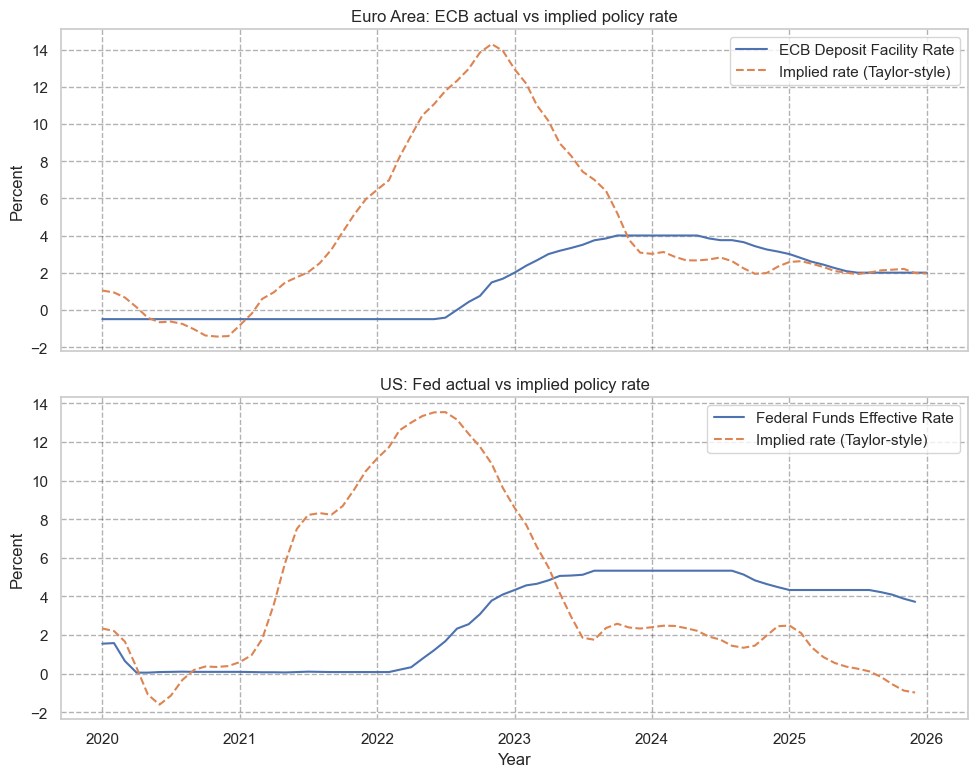

In [ ]:
# --- actual policy rates (monthly) ---
ecb = fred.get_series("ECBDFR").resample("MS").mean()      # ECB deposit facility rate (daily -> monthly avg)
fed = fred.get_series("FEDFUNDS").resample("MS").mean()    # Fed funds effective rate (monthly)

# --- inflation measures (YoY, smoothed) ---
pi_ea = yoy_sm["HICP Euro Area"]
pi_us = yoy_sm["HICP USA"]

# --- parameters for simple Taylor-style implied rate (no output gap) ---
pi_star = 2.0
r_star = 0.0

# Align and compute implied rates
ea = pd.concat({"pi": pi_ea, "actual": ecb}, axis=1).dropna()
us = pd.concat({"pi": pi_us, "actual": fed}, axis=1).dropna()

ea["implied"] = r_star + ea["pi"] + 0.5 * (ea["pi"] - pi_star)
us["implied"] = r_star + us["pi"] + 0.5 * (us["pi"] - pi_star)

# Keep common plotting window (optional)
start = "2019-01-01"
ea = ea.loc[start:]
us = us.loc[start:]

# --- plot: two panels ---
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Euro Area / ECB
axes[0].plot(ea.index, ea["actual"], label="ECB Deposit Facility Rate")
axes[0].plot(ea.index, ea["implied"], linestyle="--", label="Implied rate (Taylor-style)")
axes[0].set_title("Euro Area: ECB actual vs implied policy rate")
axes[0].set_ylabel("Percent")
axes[0].grid(alpha=0.3, ls="--")
axes[0].legend()

# US / Fed
axes[1].plot(us.index, us["actual"], label="Federal Funds Effective Rate")
axes[1].plot(us.index, us["implied"], linestyle="--", label="Implied rate (Taylor-style)")
axes[1].set_title("US: Fed actual vs implied policy rate")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Percent")
axes[1].grid(alpha=0.3, ls="--")
axes[1].legend()

axes[1].xaxis.set_major_locator(mdates.YearLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.tight_layout()
plt.show()


### Key takeaways from the “actual vs implied policy rate” figure

- **During 2021–2022**, the **implied (Taylor-style) rate** rises sharply in both the Euro Area and the US and peaks around **2022–2023**. This reflects that, when inflation surged, a simple inflation-based rule would have suggested a much higher policy rate.

- However, the **actual policy rates increased more gradually and peaked at lower levels** (especially for the ECB). This suggests that, near the inflation peak, policy may have been **behind the curve** relative to what inflation alone would imply.

- **From 2023–2024 onward**, the implied rate falls back toward roughly **2–3%**, while actual rates remain elevated for some time. This indicates that as inflation receded, policy appears **relatively tight** (actual above implied), particularly in the US.

- **Caveat:** The implied rate is **illustrative**, since it assumes $r^*=0\%$, $\pi^*=2\%$, and an output gap of zero. The figure is best interpreted in terms of **timing and direction**, not as a precise policy prescription.
